In [67]:
# import libraries
import pandas as pd
import numpy as np
from transformers import pipeline, AutoTokenizer, AutoModelForSequenceClassification
import torch
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

# load the data
all_posts_df = pd.read_csv("../01_data/clean_data/all_posts_cleaned.csv")

In [2]:
# load the different models

# roberta model finetuned on German sentences in general
model_german_general = AutoModelForSequenceClassification.from_pretrained('ssary/XLM-RoBERTa-German-sentiment')
tokenizer_german_general = AutoTokenizer.from_pretrained('ssary/XLM-RoBERTa-German-sentiment')

# roberta model finetuned on German tweets
model_german_tweets = AutoModelForSequenceClassification.from_pretrained('cardiffnlp/xlm-roberta-base-tweet-sentiment-de')
tokenizer_german_tweets = AutoTokenizer.from_pretrained('cardiffnlp/xlm-roberta-base-tweet-sentiment-de')

# bert model by Oliver Guhr
from germansentiment import SentimentModel
model_gs = SentimentModel()

In [46]:
# sample 100 posts
# sampled_posts = all_posts_df.sample(n=100, random_state=10)[["text"]]

# create an empty column to store the label
# sampled_posts["label"] = ""

# export to csv for manual labelling
# sampled_posts.to_csv("../01_data/clean_data/posts_manual_labelling.csv")

# import the sampled and labelled posts
sampled_labelled_posts = pd.read_csv("../01_data/clean_data/posts_manual_labelling.csv", usecols=["text", "label"])
sampled_labelled_posts.head()


,text,label
0,Die Union verspricht einen Industriestrompreis...,neutral
1,"Für eine Politik, die verbindet statt spaltet,...",positive
2,"Danke, Jena, für die guten Gespräche heute auf...",positive
3,(3/4) Rund 12 % der jungen Menschen in Deutsch...,negative
4,Richtiger und konsequenter Schritt der EU gege...,neutral


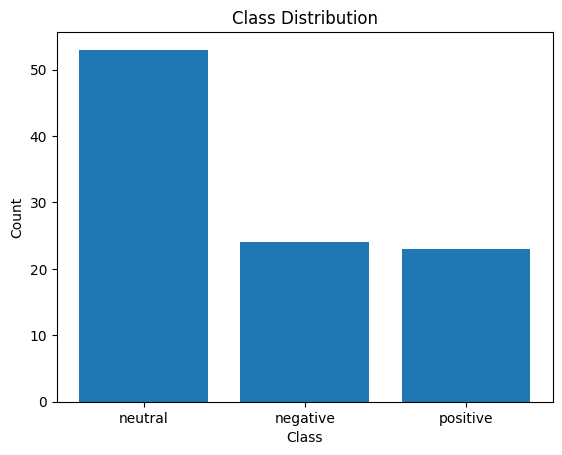

In [47]:
# plot the distribution of classes
label_counts = sampled_labelled_posts["label"].value_counts()
plt.bar(label_counts.index, label_counts.values)
plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Class Distribution")
plt.show()

In [48]:
# create a function that automates BERT sentiment prediction
def bert_predict(df, text_column, model, tokenizer):
    all_posts = df[text_column]
    all_predictions = []
    for post in all_posts:
        input_tokens = tokenizer(post, return_tensors="pt", truncation=True, max_length=512)
        with torch.no_grad():
            outputs = model(**input_tokens)
        predictions = torch.nn.functional.softmax(outputs.logits, dim=-1)
        sentiment_classes = ["negative", "neutral", "positive"]
        predicted_class = sentiment_classes[predictions.argmax()]
        all_predictions.append(predicted_class)
    return all_predictions

def bert_predict_guhr(df, text_column, model):
    all_posts = df[text_column]
    all_predictions = model.predict_sentiment(all_posts)
    return all_predictions

In [49]:
sampled_labelled_posts["prediction_cardiffnlp"] = bert_predict(sampled_labelled_posts, "text", model_german_tweets, tokenizer_german_tweets)
sampled_labelled_posts["prediction_ssary"] = bert_predict(sampled_labelled_posts, "text", model_german_general, tokenizer_german_general)
sampled_labelled_posts["prediction_guhr"] = bert_predict_guhr(sampled_labelled_posts, "text", model_gs)
sampled_labelled_posts.head()

,text,label,prediction_cardiffnlp,prediction_ssary,prediction_guhr
0,Die Union verspricht einen Industriestrompreis...,neutral,neutral,neutral,negative
1,"Für eine Politik, die verbindet statt spaltet,...",positive,positive,positive,neutral
2,"Danke, Jena, für die guten Gespräche heute auf...",positive,positive,neutral,neutral
3,(3/4) Rund 12 % der jungen Menschen in Deutsch...,negative,neutral,neutral,neutral
4,Richtiger und konsequenter Schritt der EU gege...,neutral,neutral,neutral,neutral


In [50]:
y_true = sampled_labelled_posts["label"]
prediction_models = ["cardiffnlp", "ssary", "guhr"]
for model in prediction_models:
    pred_col_name = "prediction_" + model
    y_pred = sampled_labelled_posts[pred_col_name]
    print(f"Classification report for {model}")
    print(classification_report(y_true, y_pred))
    print("-" * 80)

Classification report for cardiffnlp
              precision    recall  f1-score   support

    negative       0.76      0.67      0.71        24
     neutral       0.77      0.91      0.83        53
    positive       0.88      0.65      0.75        23

    accuracy                           0.79       100
   macro avg       0.81      0.74      0.77       100
weighted avg       0.80      0.79      0.79       100

--------------------------------------------------------------------------------
Classification report for ssary
              precision    recall  f1-score   support

    negative       0.70      0.29      0.41        24
     neutral       0.59      0.87      0.70        53
    positive       0.67      0.35      0.46        23

    accuracy                           0.61       100
   macro avg       0.65      0.50      0.52       100
weighted avg       0.63      0.61      0.58       100

--------------------------------------------------------------------------------
Classif

In [51]:
methods = ["cardiffnlp", "ssary", "guhr"]
metrics_list = []

for method in methods:
    pred_col_name = "prediction_" + method
    y_true = sampled_labelled_posts["label"]
    y_pred = sampled_labelled_posts[pred_col_name]

    # get the classification report as dictionary
    report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    
    # Loop over classes and store metrics
    for sentiment, metrics in report.items():
        # Skip 'accuracy', 'macro avg', 'weighted avg' if you only want classes
        if sentiment in ["accuracy", "macro avg", "weighted avg"]:
            continue
        metrics_list.append({
            "method": method,
            "sentiment": sentiment,
            "precision": metrics["precision"],
            "recall": metrics["recall"],
            "f1": metrics["f1-score"],
            "support": metrics["support"]
        })

# Convert to DataFrame
metrics_df = pd.DataFrame(metrics_list)
metrics_df.head()

,method,sentiment,precision,recall,f1,support
0,cardiffnlp,negative,0.761905,0.666667,0.711111,24.0
1,cardiffnlp,neutral,0.774194,0.905660,0.834783,53.0
2,cardiffnlp,positive,0.882353,0.652174,0.750000,23.0
3,ssary,negative,0.700000,0.291667,0.411765,24.0
4,ssary,neutral,0.589744,0.867925,0.702290,53.0


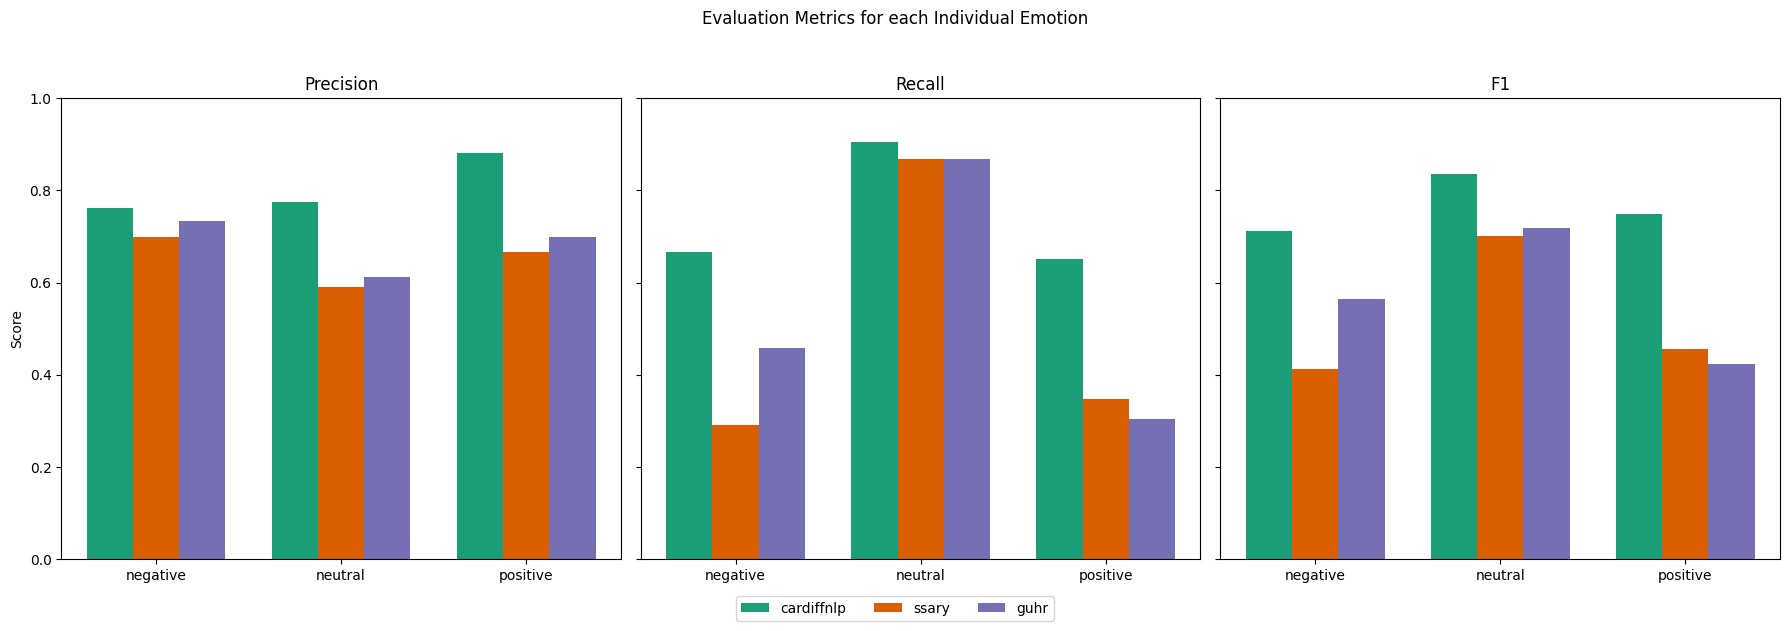

In [65]:
# create barplots to visualize the performance
metrics = ["precision", "recall", "f1"]
sentiments = ["negative", "neutral", "positive"]

cmap = plt.colormaps["Dark2"]
colors = [cmap(i) for i in range(len(methods))]

# create figure and axes for the plot
fig, axs = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
width = 0.25
x = np.arange(3)

# loop over all metrics
for idx, metric in enumerate(metrics):
    ax = axs[idx]
    
    # loop over all methods and get the corresponding scores
    for i, method in enumerate(methods):
        scores = metrics_df[metrics_df["method"] == method].set_index("sentiment")[metric].reindex(sentiments)
        ax.bar(x + i * width, scores, width=width, label=method, color=colors[i])
    
    # set title and configure the scale of the plot
    ax.set_title(metric.capitalize())
    ax.set_xticks(x + width)
    ax.set_xticklabels(sentiments)
    ax.set_ylim(0, 1.0)
    ax.set_ylabel("Score" if idx == 0 else "")

# add a legend underneath the plot
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.05), ncol=len(methods))
fig.suptitle("Evaluation Metrics for each Individual Emotion")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()